In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from matplotlib import rcParams
from pathlib import Path
import numpy as np

# 设置中文字体支持
import matplotlib.font_manager as fm
# 备选中文字体列表
chinese_fonts = [
    "SimHei",           # Windows
    "Heiti TC",         # macOS
    "WenQuanYi Micro Hei",  # Linux
    "Microsoft YaHei",  # 微软雅黑
    "Arial Unicode MS", # 备选
]

# 获取系统可用字体
available_fonts = {f.name for f in fm.fontManager.ttflist}

# 查找第一个可用的中文字体
for font in chinese_fonts:
    if font in available_fonts:
        plt.rcParams["font.family"] = font
        break

plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

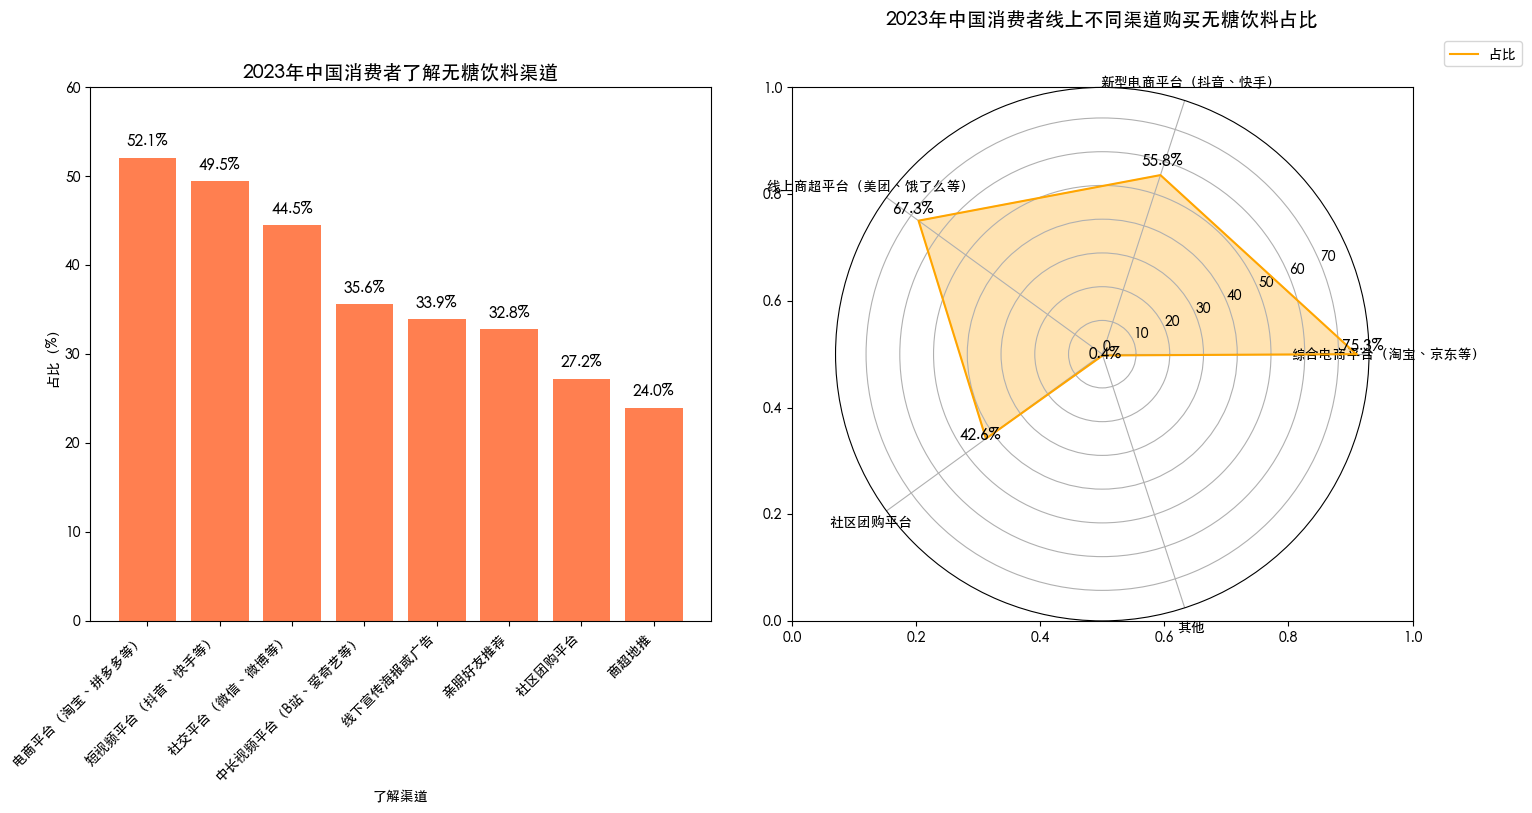

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# 数据准备（了解无糖饮料渠道）
understand_channels = [
    "电商平台（淘宝、拼多多等）", "短视频平台（抖音、快手等）", 
    "社交平台（微信、微博等）", "中长视频平台（B站、爱奇艺等）", 
    "线下宣传海报或广告", "亲朋好友推荐", 
    "社区团购平台", "商超地推"
]
understand_proportions = [52.1, 49.5, 44.5, 35.6, 33.9, 32.8, 27.2, 24.0]  # 占比（%）

# 数据准备（线上购买无糖饮料渠道占比）
purchase_channels = [
    "综合电商平台（淘宝、京东等）", "新型电商平台（抖音、快手）", 
    "线上商超平台（美团、饿了么等）", "社区团购平台", "其他"
]
purchase_proportions = [75.3, 55.8, 67.3, 42.6, 0.4]  # 占比（%）

# 创建画布（一行两列）
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# --------------------- 绘制左侧“了解渠道”柱状图 ---------------------
x_understand = np.arange(len(understand_channels))
ax1.bar(x_understand, understand_proportions, color='coral')
ax1.set_title('2023年中国消费者了解无糖饮料渠道', fontsize=14)
ax1.set_ylabel('占比（%）')
ax1.set_xlabel('了解渠道')
ax1.set_xticks(x_understand)
ax1.set_xticklabels(understand_channels, rotation=45, ha='right')
ax1.set_ylim(0, 60)  # 调整y轴范围适配最大占比（52.1%）

# 添加左侧数值标注
for i, prop in enumerate(understand_proportions):
    ax1.text(x_understand[i], prop + 1, f'{prop}%', ha='center', va='bottom', color='black', fontsize=11)

# --------------------- 绘制右侧“线上购买渠道”雷达图 ---------------------
# 雷达图角度数（渠道数量对应角度）
num_channels = len(purchase_channels)
angles = np.linspace(0, 2 * np.pi, num_channels, endpoint=False).tolist()
# 闭合雷达图（让最后一个点连回第一个点）
purchase_proportions += purchase_proportions[:1]
angles += angles[:1]

ax2 = plt.subplot(1, 2, 2, polar=True)
ax2.fill(angles, purchase_proportions, color='orange', alpha=0.3)
ax2.plot(angles, purchase_proportions, color='orange', label='占比')

# 设置雷达图的轴标签（渠道名称）
ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(purchase_channels)
# 调整y轴刻度（适配占比范围）
ax2.set_yticks(np.arange(0, 80, 10))
ax2.set_yticklabels(np.arange(0, 80, 10))

# 添加右侧数值标注
for i, (angle, prop) in enumerate(zip(angles[:-1], purchase_proportions[:-1])):
    ax2.text(angle, prop + 2, f'{prop}%', ha='center', va='bottom', color='black', fontsize=11)

ax2.set_title('2023年中国消费者线上不同渠道购买无糖饮料占比', fontsize=14, y=1.1)
ax2.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.show()

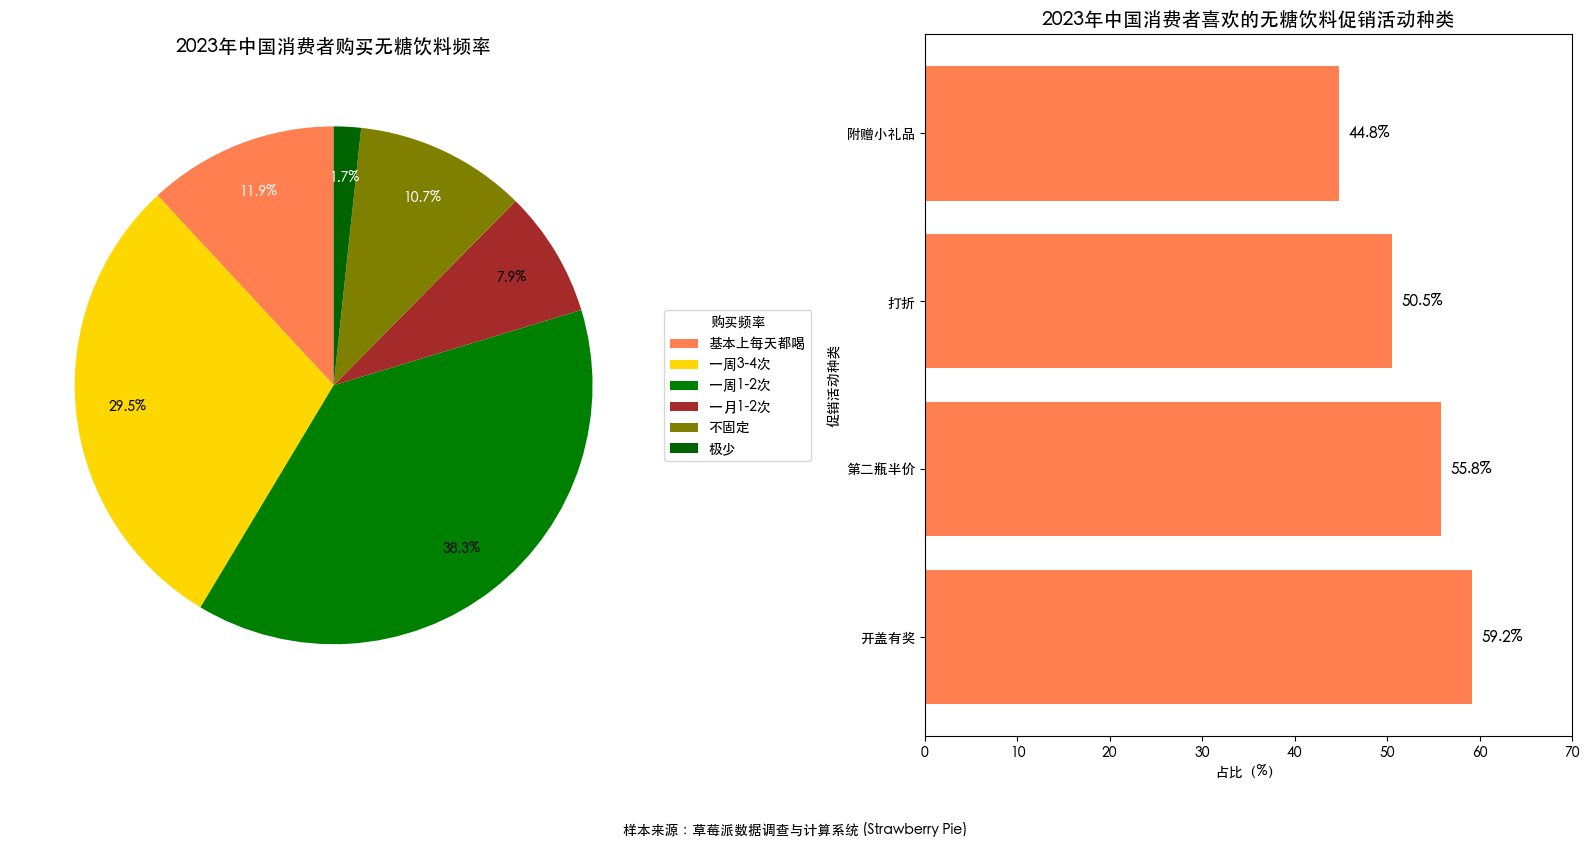

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# --------------------- 左侧“购买频率”饼图数据 ---------------------
frequency_labels = [
    "基本上每天都喝", "一周3-4次", "一周1-2次", 
    "一月1-2次", "不固定", "极少"
]
frequency_sizes = [11.9, 29.5, 38.3, 7.9, 10.7, 1.7]  # 占比（%）
frequency_colors = ["coral", "gold", "green", "brown", "olive", "darkgreen"]

# --------------------- 右侧“喜欢的促销活动”横向柱状图数据 ---------------------
promotion_labels = [
    "开盖有奖", "第二瓶半价", "打折", "附赠小礼品"
]
promotion_proportions = [59.2, 55.8, 50.5, 44.8]  # 占比（%）
promotion_colors = ["coral"] * len(promotion_labels)  # 统一橙色

# --------------------- 创建画布（一行两列） ---------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# --------------------- 绘制左侧“购买频率”饼图 ---------------------
wedges, texts, autotexts = ax1.pie(
    frequency_sizes, 
    colors=frequency_colors, 
    autopct='%1.1f%%', 
    startangle=90, 
    pctdistance=0.8  # 调整标注位置，避免重叠
)
ax1.set_title('2023年中国消费者购买无糖饮料频率', fontsize=14)
# 调整图例位置（图外右侧）
ax1.legend(
    wedges, 
    frequency_labels, 
    title="购买频率", 
    loc="center left", 
    bbox_to_anchor=(1, 0.5)
)
# 优化标注文字颜色（深色切片用白色字，浅色用黑色字）
for autotext in autotexts:
    autotext.set_color('white' if autotext.get_position()[1] > 0.5 else 'black')

# --------------------- 绘制右侧“喜欢的促销活动”横向柱状图 ---------------------
x_promotion = np.arange(len(promotion_labels))
ax2.barh(x_promotion, promotion_proportions, color=promotion_colors)
ax2.set_title('2023年中国消费者喜欢的无糖饮料促销活动种类', fontsize=14)
ax2.set_xlabel('占比（%）')
ax2.set_ylabel('促销活动种类')
ax2.set_yticks(x_promotion)
ax2.set_yticklabels(promotion_labels)
ax2.set_xlim(0, 70)  # 调整x轴范围适配最大占比（59.2%）

# 添加右侧数值标注
for i, prop in enumerate(promotion_proportions):
    ax2.text(prop + 1, i, f'{prop}%', ha='left', va='center', color='black', fontsize=11)

# --------------------- 添加样本来源说明 ---------------------
fig.text(0.5, -0.05, '样本来源：草莓派数据调查与计算系统 (Strawberry Pie)', 
         fontsize=10, ha='center')

plt.tight_layout()
plt.show()

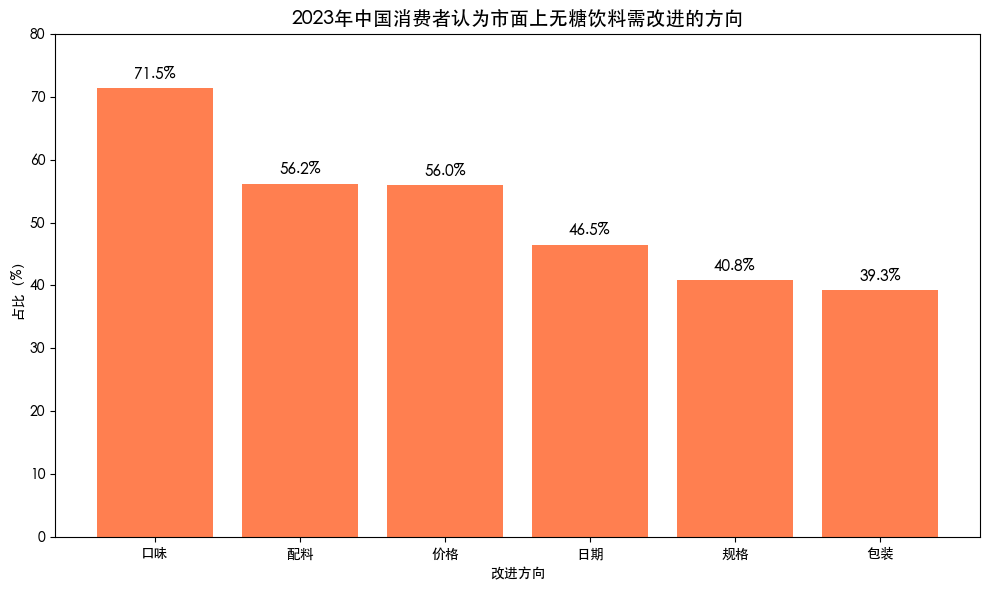

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# 数据准备
improve_directions = ["口味", "配料", "价格", "日期", "规格", "包装"]
proportions = [71.5, 56.2, 56.0, 46.5, 40.8, 39.3]  # 占比（%）

x = np.arange(len(improve_directions))

fig, ax = plt.subplots(figsize=(10, 6))

# 绘制柱状图
bars = ax.bar(x, proportions, color='coral')
ax.set_title('2023年中国消费者认为市面上无糖饮料需改进的方向', fontsize=14)
ax.set_ylabel('占比（%）')
ax.set_xlabel('改进方向')
ax.set_xticks(x)
ax.set_xticklabels(improve_directions)
ax.set_ylim(0, 80)  # 调整y轴范围，适配最大占比（71.5%）

# 添加数值标注
for i, prop in enumerate(proportions):
    ax.text(x[i], prop + 1, f'{prop}%', ha='center', va='bottom', color='black', fontsize=11)

plt.tight_layout()
plt.show()